In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Import the data


In [3]:
data = np.loadtxt(open("sample_data/mnist_train_small.csv", "rb"), delimiter=",", skiprows=1)

# we don't need the labels here
data = data[:, 1:]

# normalize the data to a range of [-1 1] (b/c tanh output)
dataNorm = data / np.max(data)
dataNorm = dataNorm * 2 - 1

dataT = torch.from_numpy(dataNorm).float().to(device)

batchsize = 200

## create the generator and discriminator


In [6]:
class discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256) # 28x28=784
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 1)

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

dnet = discriminator().to(device)

In [6]:
# testing the model 
y = dnet(torch.randn(10, 784).to(device))

y

tensor([[0.5064],
        [0.5131],
        [0.5372],
        [0.5473],
        [0.5118],
        [0.4868],
        [0.5300],
        [0.5334],
        [0.4972],
        [0.5231]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [7]:
class generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 256) # 64 is the starting size of the random noise vector
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 784)

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = torch.tanh(self.fc3(x))
        return x

gnet = generator().to(device)

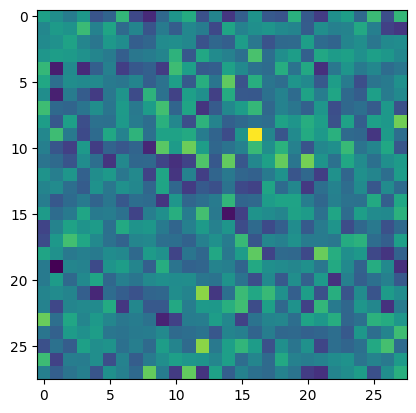

In [12]:
y = gnet(torch.randn(10, 64).to(device))

plt.imshow(y[0].detach().cpu().numpy().reshape(28, 28))
plt.show()

## training the model


In [13]:
loss = nn.BCELoss()

dnet = discriminator().to(device)
gnet = generator().to(device)

d_optimizer = torch.optim.Adam(dnet.parameters(), lr=0.0003)
g_optimizer = torch.optim.Adam(gnet.parameters(), lr=0.0003)

In [18]:
numepochs = 50000

losses = np.zeros((numepochs, 2))
disdecs = np.zeros((numepochs, 2)) # discriminator decisions for real and fake data

for i in range(numepochs):
    # create mini matches of REAL and FAKE images
    randidx = torch.randint(dataT.shape[0], (batchsize,))
    realdata = dataT[randidx, :].to(device)
    fakedata = gnet(torch.randn(batchsize, 64).to(device))

    # labels used for real and fake data
    reallabels = torch.ones(batchsize, 1).to(device)
    fakelabels = torch.zeros(batchsize, 1).to(device)

    # TRAIN THE DISCRIMINATOR
    pred_real = dnet(realdata) # giving real data to discriminator and telling them that the all labels are 1
    d_loss_real = loss(pred_real, reallabels) # all labels are 1

    pred_fake = dnet(fakedata.detach()) # detach so that gradients don't flow to generator
    d_loss_fake = loss(pred_fake, fakelabels) # giving fake data to discriminator and telling them that the all labels are 0

    # combined loss
    d_loss = d_loss_real + d_loss_fake

    losses[i, 0] = d_loss.item()
    disdecs[i, 0] = torch.mean((pred_real > 0.5).float()).detach().cpu().numpy()

    # backprop and optimize
    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    # training the generator
    fakedata = gnet(torch.randn(batchsize, 64).to(device))
    pred_fake = dnet(fakedata)
    g_loss = loss(pred_fake, reallabels) # we are lying the discriminator that the fake data is real, so we use reallabels

    losses[i, 1] = g_loss.item()
    disdecs[i, 1] = torch.mean((pred_fake > 0.5).float()).detach().cpu().numpy()

    # backprop and optimize
    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    # print the status every 1000 epochs
    if i % 1000 == 0:
        print(f"Epoch {i}: D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}, D Real Acc: {disdecs[i, 0]:.4f}, D Fake Acc: {disdecs[i, 1]:.4f}")

Epoch 0: D Loss: 1.4297, G Loss: 0.6814, D Real Acc: 0.0150, D Fake Acc: 1.0000
Epoch 1000: D Loss: 3.5019, G Loss: 1.0123, D Real Acc: 0.5100, D Fake Acc: 0.3950
Epoch 2000: D Loss: 0.8007, G Loss: 2.1559, D Real Acc: 0.8200, D Fake Acc: 0.0100
Epoch 3000: D Loss: 1.9790, G Loss: 1.5749, D Real Acc: 0.6200, D Fake Acc: 0.1650
Epoch 4000: D Loss: 0.2374, G Loss: 2.7471, D Real Acc: 0.9850, D Fake Acc: 0.0000
Epoch 5000: D Loss: 1.1815, G Loss: 1.1479, D Real Acc: 0.7050, D Fake Acc: 0.0750
Epoch 6000: D Loss: 0.9713, G Loss: 2.2008, D Real Acc: 0.8150, D Fake Acc: 0.1100
Epoch 7000: D Loss: 0.5270, G Loss: 2.2901, D Real Acc: 0.8300, D Fake Acc: 0.0050
Epoch 8000: D Loss: 0.6931, G Loss: 3.8368, D Real Acc: 0.8400, D Fake Acc: 0.0000
Epoch 9000: D Loss: 0.7006, G Loss: 2.0566, D Real Acc: 0.8800, D Fake Acc: 0.0850
Epoch 10000: D Loss: 0.6681, G Loss: 2.2407, D Real Acc: 0.7850, D Fake Acc: 0.0400
Epoch 11000: D Loss: 0.8116, G Loss: 1.8238, D Real Acc: 0.8050, D Fake Acc: 0.1550
Epoch

## vizualize the losses


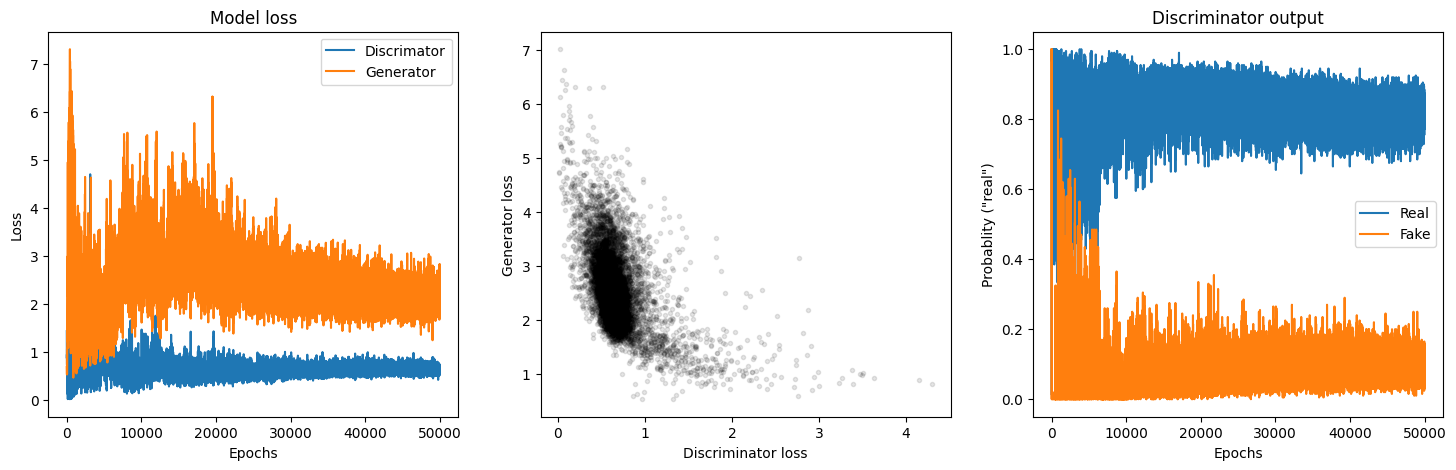

In [19]:
fig,ax = plt.subplots(1,3,figsize=(18,5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')
ax[0].legend(['Discrimator','Generator'])
# ax[0].set_xlim([4000,5000])

ax[1].plot(losses[::5,0],losses[::5,1],'k.',alpha=.1)
ax[1].set_xlabel('Discriminator loss')
ax[1].set_ylabel('Generator loss')

ax[2].plot(disdecs)
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Probablity ("real")')
ax[2].set_title('Discriminator output')
ax[2].legend(['Real','Fake'])

plt.show()

## some fake digits (data)


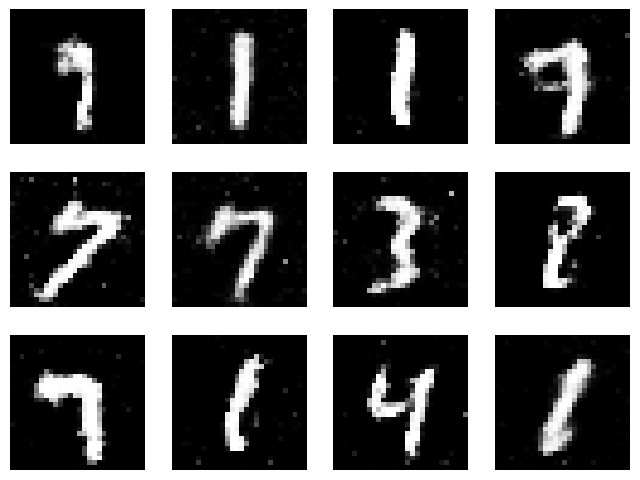

In [25]:
# generate the images from the generator network
gnet.eval()
fake_data = gnet(torch.randn(12,64).to(device)).cpu()

# and visualize
fig,axs = plt.subplots(3,4,figsize=(8,6))
for i,ax in enumerate(axs.flatten()):
  ax.imshow(fake_data[i,:,].detach().view(28,28),cmap='gray')
  ax.axis('off')

plt.show()

### **_this is see which of them descriminator was fooled that they were real, technically all of them are fake_**


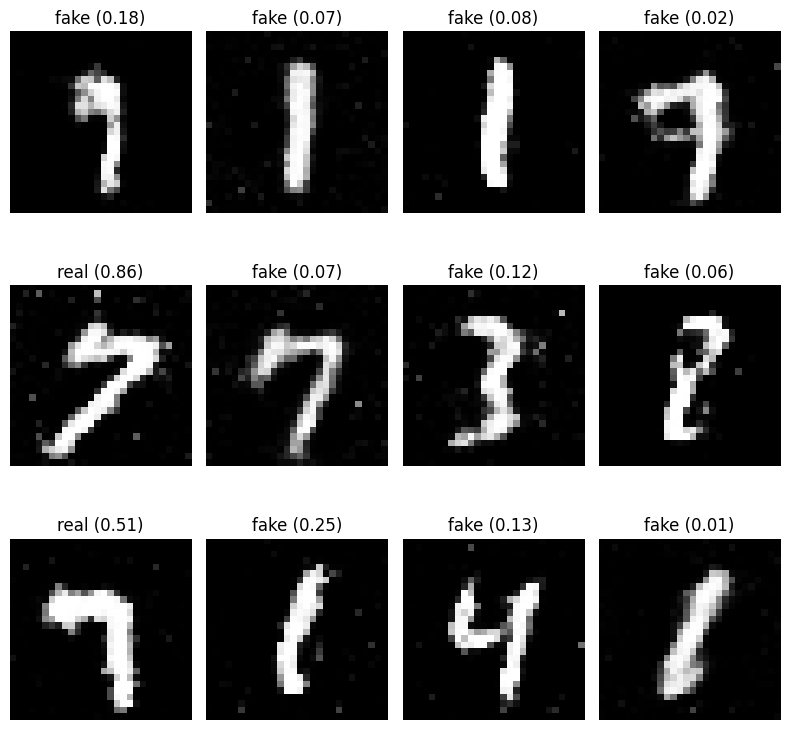

In [26]:
# put the discriminator in eval mode
dnet.eval()

# run the fake images through the discriminator
status = dnet(fake_data.to(device)).cpu()

# convert probabilities into real/fake labels (assuming sigmoid output, threshold 0.5)
labels = ['real' if s > 0.5 else 'fake' for s in status.detach().numpy().flatten()]

# visualize with discriminator's verdict as the title of each subplot
fig, axs = plt.subplots(3, 4, figsize=(8, 8))
for i, ax in enumerate(axs.flatten()):
  ax.imshow(fake_data[i, :].detach().view(28, 28), cmap='gray')
  ax.set_title(f'{labels[i]} ({status[i].item():.2f})')
  ax.axis('off')

plt.tight_layout()
plt.show()

## Linear GANs on Fashion-MNIST Subsets

In this section, we train the **same `generator` and `discriminator` classes** defined earlier on Fashion-MNIST subset classes.
We implement the training loop in a dedicated function named `train_gan` that processes **50,000 batches** using `DataLoader` and applies **loss function smoothing** (one-sided label smoothing + moving average curve visualization).

### Tasks:

1. **Experiment 1**: Train on **Trouser (1)**, **Sneaker (7)**, **Pullover (2)**.
2. **Experiment 2**: Train on **Trouser (1)**, **Sneaker (7)**, **Sandal (5)**.


In [3]:
# DataLoader helper for Fashion-MNIST filtered target classes
def get_fmnist_dataloader(target_classes, batch_size=200):
    """
    Fashion-MNIST Class Index Reference:
    0: T-shirt/top, 1: Trouser, 2: Pullover, 3: Dress, 4: Coat,
    5: Sandal, 6: Shirt, 7: Sneaker, 8: Bag, 9: Ankle boot
    """
    transform = T.Compose([
        T.ToTensor(),
        T.Normalize((0.5,), (0.5,))  # scale image pixels from [0, 1] to [-1, 1]
    ])
    
    train_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=True, download=True, transform=transform
    )
    
    target_set = set(target_classes)
    indices = [i for i, label in enumerate(train_dataset.targets.tolist()) if label in target_set]
    subset = Subset(train_dataset, indices)
    
    return DataLoader(subset, batch_size=batch_size, shuffle=True, drop_last=True)

def cycle(dataloader):
    """Infinite generator over a PyTorch DataLoader."""
    while True:
        for batch in dataloader:
            yield batch

In [4]:
# Loss smoothing function (Moving average for loss visualization)
def moving_average(data, window_size=500):
    if len(data) < window_size:
        return data
    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode='valid')

# The core train_gan function requested to loop over 50,000 batches
def train_gan(target_classes, class_names, num_batches=50000, batch_size=200, smooth_factor=0.9):
    print(f"\n=======================================================")
    print(f" Training GAN on classes: {class_names} (Labels: {target_classes})")
    print(f" Total Batches: {num_batches} | Batch Size: {batch_size}")
    print(f" One-Sided Label Smoothing Factor: {smooth_factor}")
    print(f"=======================================================\n")
    
    # DataLoader iterator
    dataloader = get_fmnist_dataloader(target_classes, batch_size=batch_size)
    data_iter = iter(cycle(dataloader))
    
    # Instantiate using the PREVIOUS generator and discriminator classes from above cells
    dnet = discriminator().to(device)
    gnet = generator().to(device)
    
    loss_fn = nn.BCELoss()
    d_optimizer = torch.optim.Adam(dnet.parameters(), lr=0.0003)
    g_optimizer = torch.optim.Adam(gnet.parameters(), lr=0.0003)
    
    losses = np.zeros((num_batches, 2))
    disdecs = np.zeros((num_batches, 2))
    
    for i in range(num_batches):
        # Fetch mini-batch of REAL and FAKE images
        realdata, _ = next(data_iter)
        realdata = realdata.view(batch_size, -1).to(device)
        fakedata = gnet(torch.randn(batch_size, 64).to(device))
        
        # Smooth loss function: One-sided label smoothing (soft real labels = 0.9 instead of 1.0)
        reallabels_smooth = torch.full((batch_size, 1), smooth_factor, device=device)
        fakelabels = torch.zeros(batch_size, 1).to(device)
        reallabels_hard = torch.ones(batch_size, 1).to(device)
        
        # TRAIN DISCRIMINATOR
        pred_real = dnet(realdata)
        d_loss_real = loss_fn(pred_real, reallabels_smooth)
        
        pred_fake = dnet(fakedata.detach())
        d_loss_fake = loss_fn(pred_fake, fakelabels)
        
        d_loss = d_loss_real + d_loss_fake
        
        losses[i, 0] = d_loss.item()
        disdecs[i, 0] = torch.mean((pred_real > 0.5).float()).detach().cpu().numpy()
        
        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()
        
        # TRAIN GENERATOR
        fakedata = gnet(torch.randn(batch_size, 64).to(device))
        pred_fake = dnet(fakedata)
        g_loss = loss_fn(pred_fake, reallabels_hard)
        
        losses[i, 1] = g_loss.item()
        disdecs[i, 1] = torch.mean((pred_fake > 0.5).float()).detach().cpu().numpy()
        
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()
        
        if i % 5000 == 0:
            print(f"Batch {i:5d}: D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}, D Real Acc: {disdecs[i, 0]:.4f}, D Fake Acc: {disdecs[i, 1]:.4f}")
            
    # VISUALIZE SMOOTH LOSS CURVES & ACCURACIES
    window_size = 500
    d_loss_smooth = moving_average(losses[:, 0], window_size)
    g_loss_smooth = moving_average(losses[:, 1], window_size)
    smooth_x = np.arange(window_size - 1, num_batches)
    
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    # BCE Loss curves (Raw transparent + Solid Moving Average)
    axs[0].plot(losses[:, 0], alpha=0.2, color='blue', label='D Loss (raw)')
    axs[0].plot(losses[:, 1], alpha=0.2, color='red', label='G Loss (raw)')
    axs[0].plot(smooth_x, d_loss_smooth, color='darkblue', linewidth=2, label=f'D Loss ({window_size}-batch MA)')
    axs[0].plot(smooth_x, g_loss_smooth, color='darkred', linewidth=2, label=f'G Loss ({window_size}-batch MA)')
    axs[0].set_xlabel('Batch Iteration')
    axs[0].set_ylabel('BCE Loss')
    axs[0].set_title(f'Smoothed Loss Curves ({", ".join(class_names)})')
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.5)
    
    # Discriminator Decision Accuracy
    d_real_smooth = moving_average(disdecs[:, 0], window_size)
    d_fake_smooth = moving_average(disdecs[:, 1], window_size)
    axs[1].plot(smooth_x, d_real_smooth, color='green', linewidth=2, label='D Real Accuracy (MA)')
    axs[1].plot(smooth_x, d_fake_smooth, color='purple', linewidth=2, label='D Fake Accuracy (MA)')
    axs[1].set_xlabel('Batch Iteration')
    axs[1].set_ylabel('Accuracy / Decision')
    axs[1].set_title(f'Discriminator Decision Accuracy ({", ".join(class_names)})')
    axs[1].legend()
    axs[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # VISUALIZE GENERATED SAMPLE GRID
    gnet.eval()
    with torch.no_grad():
        fake_samples = gnet(torch.randn(12, 64).to(device)).cpu()
    
    fig, axs = plt.subplots(3, 4, figsize=(8, 6))
    fig.suptitle(f'Generated Samples for {", ".join(class_names)}', fontsize=14)
    for idx, ax in enumerate(axs.flatten()):
        ax.imshow(fake_samples[idx].view(28, 28), cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    return gnet, dnet, losses, disdecs

### 1. Train GAN on Trouser, Sneaker, Pullover (50,000 Batches)



 Training GAN on classes: ['Trouser', 'Sneaker', 'Pullover'] (Labels: [1, 7, 2])
 Total Batches: 50000 | Batch Size: 200
 One-Sided Label Smoothing Factor: 0.9

Batch     0: D Loss: 1.3773, G Loss: 0.6868, D Real Acc: 0.8700, D Fake Acc: 0.9950
Batch  5000: D Loss: 0.4751, G Loss: 4.9657, D Real Acc: 0.9300, D Fake Acc: 0.0000
Batch 10000: D Loss: 0.7567, G Loss: 2.7062, D Real Acc: 0.7700, D Fake Acc: 0.0350
Batch 15000: D Loss: 0.7799, G Loss: 2.2885, D Real Acc: 0.7700, D Fake Acc: 0.0200
Batch 20000: D Loss: 1.0221, G Loss: 1.8737, D Real Acc: 0.7850, D Fake Acc: 0.0600
Batch 25000: D Loss: 1.0374, G Loss: 1.8250, D Real Acc: 0.6000, D Fake Acc: 0.0850
Batch 30000: D Loss: 1.0775, G Loss: 1.2426, D Real Acc: 0.6500, D Fake Acc: 0.2850
Batch 35000: D Loss: 1.4120, G Loss: 1.2014, D Real Acc: 0.5550, D Fake Acc: 0.2550
Batch 40000: D Loss: 0.9863, G Loss: 1.6068, D Real Acc: 0.6900, D Fake Acc: 0.1000
Batch 45000: D Loss: 1.0612, G Loss: 1.5236, D Real Acc: 0.7000, D Fake Acc: 0.110

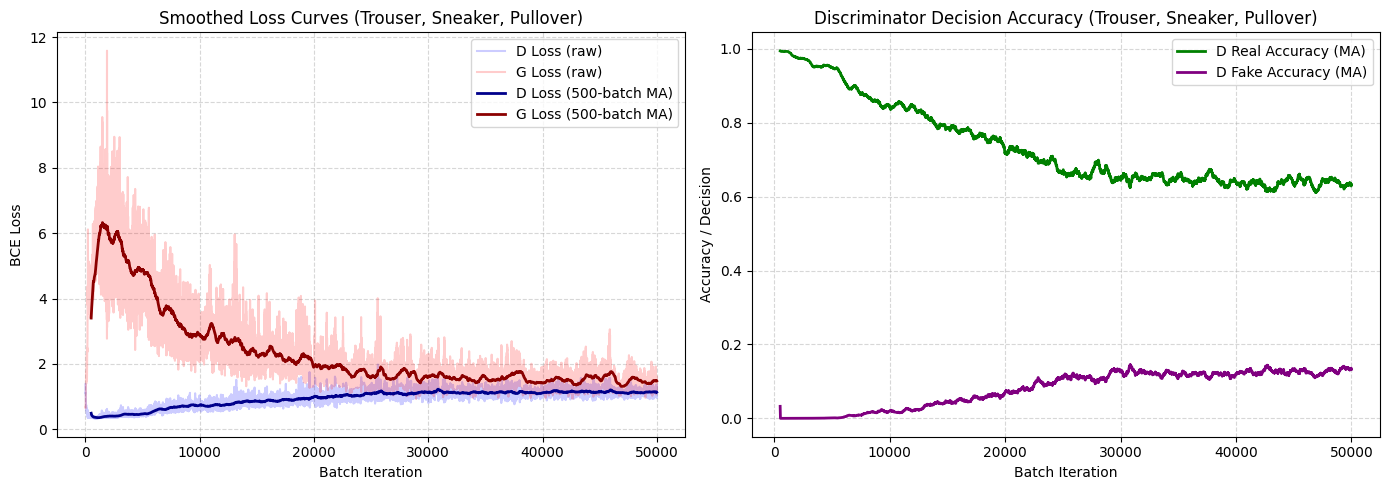

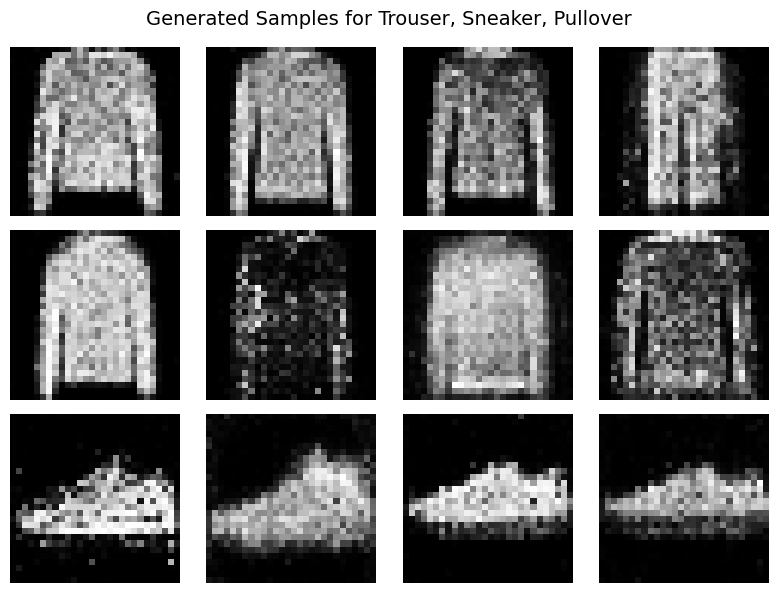

In [14]:
# Experiment 1: Trouser (1), Sneaker (7), Pullover (2)
exp1_classes = [1, 7, 2]
exp1_names = ['Trouser', 'Sneaker', 'Pullover']
gnet_exp1, dnet_exp1, losses_exp1, disdecs_exp1 = train_gan(exp1_classes, exp1_names, num_batches=50000)

### 2. Train GAN on Trouser, Sneaker, Sandal (50,000 Batches)



 Training GAN on classes: ['Trouser', 'Sneaker', 'Sandal'] (Labels: [1, 7, 5])
 Total Batches: 50000 | Batch Size: 200
 One-Sided Label Smoothing Factor: 0.9

Batch     0: D Loss: 1.3961, G Loss: 0.7061, D Real Acc: 0.1400, D Fake Acc: 0.0000
Batch  5000: D Loss: 0.7193, G Loss: 1.9988, D Real Acc: 0.8000, D Fake Acc: 0.0050
Batch 10000: D Loss: 0.9076, G Loss: 2.0796, D Real Acc: 0.7450, D Fake Acc: 0.0150
Batch 15000: D Loss: 0.9588, G Loss: 3.5396, D Real Acc: 0.7850, D Fake Acc: 0.0500
Batch 20000: D Loss: 0.8307, G Loss: 2.4230, D Real Acc: 0.7450, D Fake Acc: 0.0150
Batch 25000: D Loss: 0.9257, G Loss: 1.9352, D Real Acc: 0.7350, D Fake Acc: 0.0250
Batch 30000: D Loss: 0.9075, G Loss: 2.0884, D Real Acc: 0.7600, D Fake Acc: 0.0250
Batch 35000: D Loss: 1.2195, G Loss: 2.2770, D Real Acc: 0.6100, D Fake Acc: 0.1150
Batch 40000: D Loss: 1.0228, G Loss: 1.8057, D Real Acc: 0.7550, D Fake Acc: 0.0350
Batch 45000: D Loss: 0.9414, G Loss: 2.0788, D Real Acc: 0.6550, D Fake Acc: 0.0300


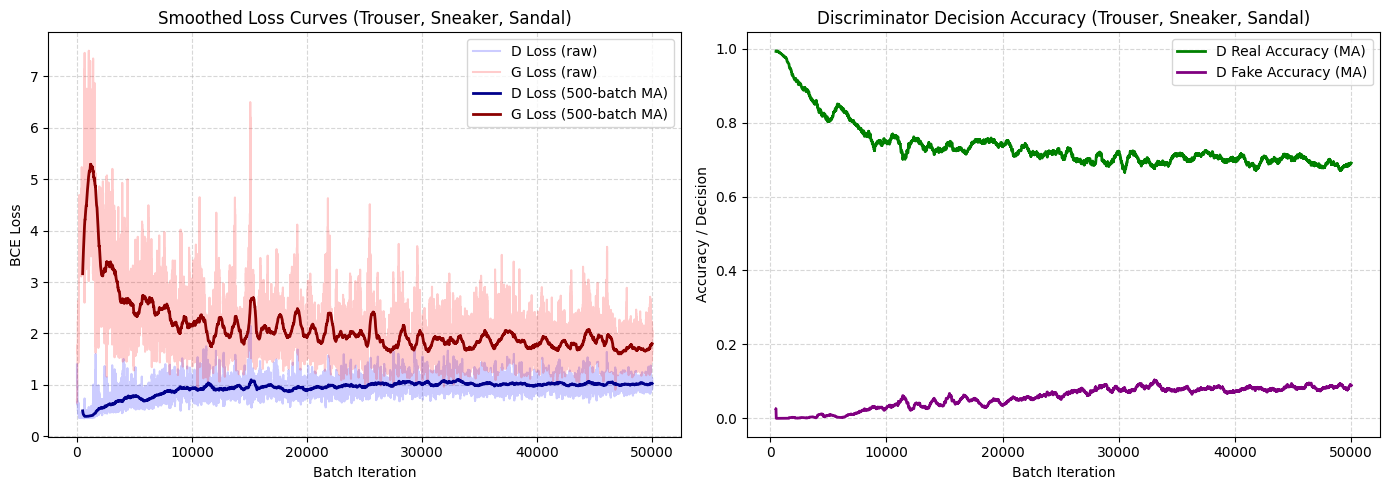

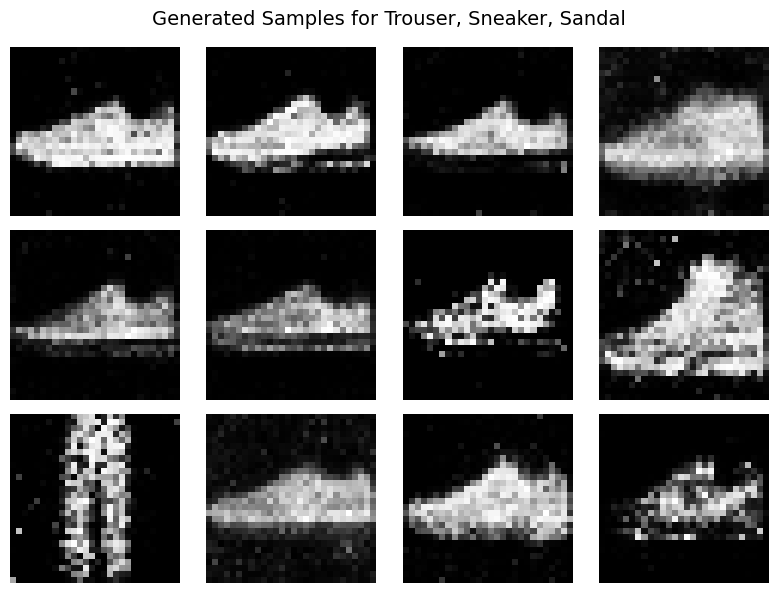

In [8]:
# Experiment 2: Trouser (1), Sneaker (7), Sandal (5)
exp2_classes = [1, 7, 5]
exp2_names = ['Trouser', 'Sneaker', 'Sandal']
gnet_exp2, dnet_exp2, losses_exp2, disdecs_exp2 = train_gan(exp2_classes, exp2_names, num_batches=50000)